# Stratified Fairness Analysis

Analyze whether overall fairness masks group differences in severity composition.

## Key Question

**Does "fair" completeness coexist with large severity disparities?**

If yes: Overall fairness metrics mask selection bias earlier in the reporting pipeline.

## Analysis

1. **Fairness Within Severity Strata** - Does fairness hold when we stratify by severity?
2. **Severity Mix by Group** - How do injury distributions differ between groups?
3. **Implication** - Can groups have same completeness but different injury severity?


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
sns.set_palette('colorblind')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported")

✓ Libraries imported


## Load Data and Model

In [2]:
# Load the original raw data (to get Injury Severity column)
df_raw = pd.read_csv('WA_Crash_Summary_2025.csv')

# Load the processed data
df_processed = pd.read_csv('../extension/wa_vru_data_quality.csv')

# Load test set
X_test = pd.read_csv('../extension/X_test.csv')
y_test = pd.read_csv('../extension/y_test.csv').values.ravel()

# Load trained model
with open('../extension/decision_tree_model.pkl', 'rb') as f:
    dt_model = pickle.load(f)

print(f"✓ Data loaded")
print(f"  Raw data: {len(df_raw):,} crashes")
print(f"  Processed data: {len(df_processed):,} crashes")
print(f"  Test set: {len(X_test):,} samples")

✓ Data loaded
  Raw data: 137,716 crashes
  Processed data: 15,000 crashes
  Test set: 3,000 samples


## Data Preparation: Merge Severity Information

In [3]:
# Check if raw data has the index we can merge on
print("Raw data columns:")
print(df_raw.columns.tolist()[:10])  # Show first 10 columns
print(f"\nRaw data shape: {df_raw.shape}")
print(f"\nInjury Severity values:")
print(df_raw['Injury Severity'].value_counts())

Raw data columns:
['Collision Report Number', 'Collision Date', 'County', 'City', 'Jurisdiction', 'Agency', 'Primary Trafficway', 'Secondary Trafficway', 'Block Number', 'Mile Post']

Raw data shape: (137716, 24)

Injury Severity values:
Injury Severity
No Injury Collision         93291
Minor Injury Collision      29970
Unknown Injury Collision    10474
Serious Injury Collision     3176
Fatal Collision               805
Name: count, dtype: int64


In [4]:
# First, let's see what the ACTUAL values are in the Injury Severity column
print("Actual Injury Severity values in data:")
print("="*70)
actual_values = df_raw['Injury Severity'].value_counts(dropna=False)
print(actual_values)
print(f"\nUnique values: {df_raw['Injury Severity'].unique()[:20]}")  # Show first 20

# Create stratification variable from Injury Severity
# Based on actual WA crash data values:
# Minor: No Injury Collision, Minor Injury Collision
# Serious: Serious Injury Collision, Fatal Collision
# Unknown: Unknown Injury Collision

severity_mapping = {}
for val in df_raw['Injury Severity'].dropna().unique():
    val_clean = str(val).strip() if pd.notna(val) else val
    if any(x in val_clean for x in ['No Injury', 'Minor Injury']):
        severity_mapping[val] = 'Minor'
    elif 'Unknown' in val_clean:
        severity_mapping[val] = 'Unknown'
    elif any(x in val_clean for x in ['Serious', 'Fatal']):
        severity_mapping[val] = 'Serious'
    else:
        severity_mapping[val] = 'Other'

print(f"\n\nCreated mapping for {len(severity_mapping)} unique values:")
for k, v in severity_mapping.items():
    print(f"  '{k}' -> '{v}'")

df_raw['severity_stratum'] = df_raw['Injury Severity'].map(severity_mapping)

print("\n\nSeverity Strata Created")
print("="*70)
print(df_raw['severity_stratum'].value_counts(dropna=False))
print(f"\nProportion by stratum:")
print(df_raw['severity_stratum'].value_counts(normalize=True).apply(lambda x: f"{x*100:.1f}%"))

Actual Injury Severity values in data:
Injury Severity
No Injury Collision         93291
Minor Injury Collision      29970
Unknown Injury Collision    10474
Serious Injury Collision     3176
Fatal Collision               805
Name: count, dtype: int64

Unique values: ['Unknown Injury Collision' 'Minor Injury Collision' 'No Injury Collision'
 'Serious Injury Collision' 'Fatal Collision']


Created mapping for 5 unique values:
  'Unknown Injury Collision' -> 'Unknown'
  'Minor Injury Collision' -> 'Minor'
  'No Injury Collision' -> 'Minor'
  'Serious Injury Collision' -> 'Serious'
  'Fatal Collision' -> 'Serious'


Severity Strata Created
severity_stratum
Minor      123261
Unknown     10474
Serious      3981
Name: count, dtype: int64

Proportion by stratum:
severity_stratum
Minor      89.5%
Unknown     7.6%
Serious     2.9%
Name: proportion, dtype: object


## Part A: Severity Mix by Group

First, let's examine how severity distributions differ between VRU and non-VRU crashes.

In [5]:
# Create VRU indicator in raw data
df_raw['is_vru'] = (
    (df_raw['Pedestrians Involved'] > 0) | 
    (df_raw['Pedalcyclists Involved'] > 0)
).astype(int)

print(f"VRU crashes in raw data: {df_raw['is_vru'].sum():,} ({df_raw['is_vru'].mean()*100:.1f}%)")

VRU crashes in raw data: 5,234 (3.8%)


In [6]:
# Crosstab: Severity distribution by VRU status
severity_by_vru = pd.crosstab(
    df_raw['is_vru'].map({0: 'Non-VRU', 1: 'VRU'}),
    df_raw['Injury Severity'],
    normalize='index'
) * 100  # Convert to percentage

print("INJURY SEVERITY DISTRIBUTION BY GROUP")
print("="*70)
print("(Percentages within each group)\n")
print(severity_by_vru.round(1))

INJURY SEVERITY DISTRIBUTION BY GROUP
(Percentages within each group)

Injury Severity  Fatal Collision  Minor Injury Collision  No Injury Collision  \
is_vru                                                                          
Non-VRU                      0.4                    20.1                 70.0   
VRU                          5.3                    64.1                 11.1   

Injury Severity  Serious Injury Collision  Unknown Injury Collision  
is_vru                                                               
Non-VRU                               1.7                       7.8  
VRU                                  17.7                       1.8  


In [7]:
# First, check if severity_stratum has NaN values
print("Checking severity_stratum:")
print(df_raw['severity_stratum'].value_counts(dropna=False))
print(f"\nNaN count: {df_raw['severity_stratum'].isna().sum()}")

# Crosstab: Severity stratum by VRU status (drop NaN)
df_valid = df_raw[df_raw['severity_stratum'].notna()].copy()

if len(df_valid) == 0:
    print("\n⚠️  ERROR: No valid severity stratum data found!")
    print("Check the severity_mapping against actual Injury Severity values.")
else:
    stratum_by_vru = pd.crosstab(
        df_valid['is_vru'].map({0: 'Non-VRU', 1: 'VRU'}),
        df_valid['severity_stratum'],
        normalize='index'
    ) * 100

    print("\nSEVERITY STRATUM DISTRIBUTION BY GROUP")
    print("="*70)
    print("(Percentages within each group)\n")
    print(stratum_by_vru.round(1))

    # Compute difference
    if 'Serious' in stratum_by_vru.columns:
        diff_serious = stratum_by_vru.loc['VRU', 'Serious'] - stratum_by_vru.loc['Non-VRU', 'Serious']
        print(f"\n⚠️  KEY FINDING: VRU crashes have {diff_serious:+.1f}% higher serious injury rate")
    
    if 'Minor' in stratum_by_vru.columns and 'Serious' in stratum_by_vru.columns:
        print(f"\nVRU: {stratum_by_vru.loc['VRU', 'Serious']:.1f}% serious, {stratum_by_vru.loc['VRU', 'Minor']:.1f}% minor")
        print(f"Non-VRU: {stratum_by_vru.loc['Non-VRU', 'Serious']:.1f}% serious, {stratum_by_vru.loc['Non-VRU', 'Minor']:.1f}% minor")

Checking severity_stratum:
severity_stratum
Minor      123261
Unknown     10474
Serious      3981
Name: count, dtype: int64

NaN count: 0

SEVERITY STRATUM DISTRIBUTION BY GROUP
(Percentages within each group)

severity_stratum  Minor  Serious  Unknown
is_vru                                   
Non-VRU            90.1      2.1      7.8
VRU                75.2     23.0      1.8

⚠️  KEY FINDING: VRU crashes have +20.9% higher serious injury rate

VRU: 23.0% serious, 75.2% minor
Non-VRU: 2.1% serious, 90.1% minor


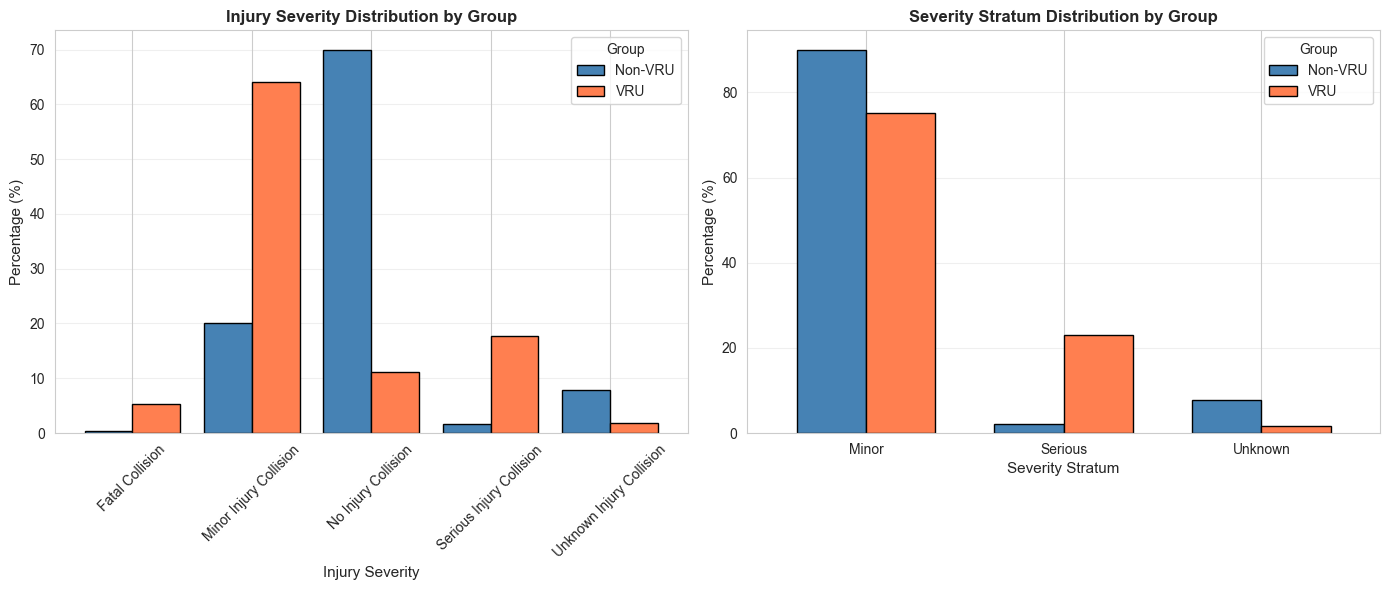


✓ Severity distribution visualization saved


In [8]:
# Visualize severity distribution
if len(df_valid) > 0 and 'stratum_by_vru' in locals():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot 1: Detailed severity categories
    severity_by_vru_T = severity_by_vru.T
    severity_by_vru_T.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], 
                           edgecolor='black', width=0.8)
    axes[0].set_xlabel('Injury Severity', fontsize=11)
    axes[0].set_ylabel('Percentage (%)', fontsize=11)
    axes[0].set_title('Injury Severity Distribution by Group', fontsize=12, fontweight='bold')
    axes[0].legend(title='Group', loc='upper right')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(axis='y', alpha=0.3)

    # Plot 2: Simplified strata
    stratum_by_vru_T = stratum_by_vru.T
    stratum_by_vru_T.plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'],
                          edgecolor='black', width=0.7)
    axes[1].set_xlabel('Severity Stratum', fontsize=11)
    axes[1].set_ylabel('Percentage (%)', fontsize=11)
    axes[1].set_title('Severity Stratum Distribution by Group', fontsize=12, fontweight='bold')
    axes[1].legend(title='Group', loc='upper right')
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('../extension/severity_distribution_by_group.png',
                dpi=300, bbox_inches='tight')
    plt.show()

    print("\n✓ Severity distribution visualization saved")
else:
    print("\n⚠️ Skipping visualization - no valid severity stratum data")

## Statistical Test: Are Severity Distributions Different?

In [9]:
# Chi-square test for independence
contingency_table = pd.crosstab(
    df_raw['is_vru'],
    df_raw['severity_stratum']
)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print("CHI-SQUARE TEST: VRU Status × Severity Stratum")
print("="*70)
print(f"Chi-square statistic: {chi2:.2f}")
print(f"p-value: {p_value:.4e}")
print(f"Degrees of freedom: {dof}")

if p_value < 0.001:
    print(f"\n✓ STATISTICALLY SIGNIFICANT: VRU and non-VRU crashes have")
    print(f"  different severity distributions (p < 0.001)")
else:
    print(f"\nℹ No significant difference detected")

CHI-SQUARE TEST: VRU Status × Severity Stratum
Chi-square statistic: 7995.55
p-value: 0.0000e+00
Degrees of freedom: 2

✓ STATISTICALLY SIGNIFICANT: VRU and non-VRU crashes have
  different severity distributions (p < 0.001)


## Part B: Fairness Within Severity Strata

Now let's compute fairness metrics **separately** for each severity stratum.

In [10]:
# We need to merge severity stratum info with our test set
# For this analysis, let's work with the full processed dataset that has injury_definitive

# Note: Since we don't have a direct merge key, we'll approximate by creating
# severity_stratum in the processed data based on the injury_definitive target

# Alternative approach: Use the model predictions on stratified subsets
# Let's create synthetic strata based on our severity proxy from notebook 2

# Load the data with severity proxy if available, or recreate it
df_analysis = df_processed.copy()

# Recreate severity proxy
df_analysis['severity_proxy'] = (
    df_analysis['hit_and_run'] * 0.3 +
    df_analysis['night_crash'] * 0.2 +
    df_analysis['adverse_weather'] * 0.2 +
    df_analysis['intersection'] * 0.15 +
    df_analysis['multiple_vehicles'] * 0.15
)

# Create severity strata based on median split
median_severity = df_analysis['severity_proxy'].median()
df_analysis['severity_stratum'] = np.where(
    df_analysis['severity_proxy'] > median_severity,
    'High Severity',
    'Low Severity'
)

print("Severity Strata Created (Proxy-Based)")
print("="*70)
print(df_analysis['severity_stratum'].value_counts())
print(f"\nMedian severity proxy: {median_severity:.3f}")

Severity Strata Created (Proxy-Based)
severity_stratum
Low Severity     9067
High Severity    5933
Name: count, dtype: int64

Median severity proxy: 0.300


In [15]:
# Function to compute fairness metrics for a subset
def compute_fairness_stratified(df, group_col='is_vru', target_col='injury_definitive'):
    """
    Compute fairness metrics for a dataframe subset.
    
    Returns:
        dict with p_vru, p_nonvru, DI, SPD
    """
    # Group-wise positive rates
    p_nonvru = df[df[group_col] == 0][target_col].mean()
    p_vru = df[df[group_col] == 1][target_col].mean()
    
    # Fairness metrics
    p_max = max(p_vru, p_nonvru)
    p_min = min(p_vru, p_nonvru)
    
    DI = p_min / p_max if p_max > 0 else 0
    SPD = p_max - p_min
    
    return {
        'p_nonvru': p_nonvru,
        'p_vru': p_vru,
        'p_max': p_max,
        'p_min': p_min,
        'DI': DI,
        'SPD': SPD,
        'n': len(df)
    }

print("✓ Fairness computation function defined")

✓ Fairness computation function defined


In [16]:
# Compute fairness for each stratum
print("FAIRNESS WITHIN SEVERITY STRATA")
print("="*70)

strata_results = {}

for stratum in df_analysis['severity_stratum'].unique():
    df_stratum = df_analysis[df_analysis['severity_stratum'] == stratum]
    results = compute_fairness_stratified(df_stratum)
    strata_results[stratum] = results
    
    print(f"\n{stratum} (n={results['n']:,}):")
    print(f"  Non-VRU completeness: {results['p_nonvru']:.1%}")
    print(f"  VRU completeness:     {results['p_vru']:.1%}")
    print(f"  Disparate Impact:     {results['DI']:.3f}")
    print(f"  Stat. Parity Diff:    {results['SPD']:.3f}")
    
    if results['DI'] < 0.8:
        print(f"  ⚠️  BIAS in {stratum} stratum (DI < 0.8)")
    else:
        print(f"  ✓  Fair in {stratum} stratum")

# Overall (unstratified)
overall_results = compute_fairness_stratified(df_analysis)
strata_results['Overall'] = overall_results

print(f"\nOverall (Unstratified, n={overall_results['n']:,}):")
print(f"  Non-VRU completeness: {overall_results['p_nonvru']:.1%}")
print(f"  VRU completeness:     {overall_results['p_vru']:.1%}")
print(f"  Disparate Impact:     {overall_results['DI']:.3f}")
print(f"  Stat. Parity Diff:    {overall_results['SPD']:.3f}")

FAIRNESS WITHIN SEVERITY STRATA

High Severity (n=5,933):
  Non-VRU completeness: 83.9%
  VRU completeness:     97.3%
  Disparate Impact:     0.863
  Stat. Parity Diff:    0.133
  ✓  Fair in High Severity stratum

Low Severity (n=9,067):
  Non-VRU completeness: 97.6%
  VRU completeness:     98.7%
  Disparate Impact:     0.989
  Stat. Parity Diff:    0.011
  ✓  Fair in Low Severity stratum

Overall (Unstratified, n=15,000):
  Non-VRU completeness: 92.2%
  VRU completeness:     98.2%
  Disparate Impact:     0.938
  Stat. Parity Diff:    0.061


In [17]:
# Create summary table
summary_df = pd.DataFrame([
    {
        'Stratum': stratum,
        'n': results['n'],
        'Non-VRU_Completeness': results['p_nonvru'],
        'VRU_Completeness': results['p_vru'],
        'DI': results['DI'],
        'SPD': results['SPD']
    }
    for stratum, results in strata_results.items()
])

print("\nSTRATIFIED FAIRNESS SUMMARY TABLE")
print("="*70)
print(summary_df.to_string(index=False))

# Save to CSV
summary_df.to_csv('../extension/stratified_fairness_results.csv', index=False)
print("\n✓ Results saved to stratified_fairness_results.csv")


STRATIFIED FAIRNESS SUMMARY TABLE
      Stratum     n  Non-VRU_Completeness  VRU_Completeness       DI      SPD
High Severity  5933              0.839332          0.972527 0.863042 0.133195
 Low Severity  9067              0.976149          0.987113 0.988893 0.010964
      Overall 15000              0.921622          0.982456 0.938079 0.060835

✓ Results saved to stratified_fairness_results.csv


## Visualization: Fairness Across Strata

Creating enhanced fairness visualization...


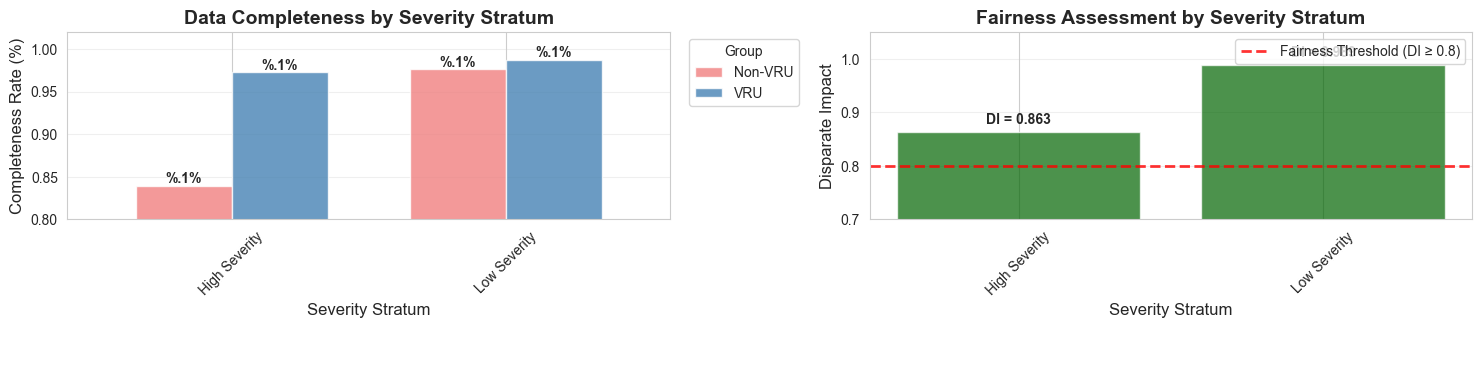


✅ Enhanced visualization with comprehensive information display created!
📊 Left: Completeness rates with precise percentage values
⚖️  Right: Fairness assessment with DI and SPD values, color-coded by fairness status
📍 Red dashed line indicates fairness threshold (DI ≥ 0.8)
🟢 Green bars = Fair, 🔴 Red bars = Biased
💾 Saved as: stratified_fairness_analysis.png


In [ ]:
# Create improved comparison of completeness rates across severity strata
print("Creating stratified fairness analysis visualization...")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Completeness by Group Within Severity Strata
strata_completeness = {}
for stratum in strata_results.keys():
    if stratum != 'Overall':
        strata_completeness[stratum] = {
            'Non-VRU': strata_results[stratum]['p_nonvru'],
            'VRU': strata_results[stratum]['p_vru']
        }

completeness_df = pd.DataFrame(strata_completeness).T
completeness_df.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], 
                     width=0.7, alpha=0.85)
axes[0].set_xlabel('Severity Stratum', fontsize=11)
axes[0].set_ylabel('Reporting Completeness Rate', fontsize=11)
axes[0].set_title('Completeness by Group Within Severity Strata', fontsize=12, fontweight='bold')
axes[0].legend(title='Group', loc='lower right')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0.80, 1.00)

# Add value labels on each bar
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.2f%%', label_type='edge', fontsize=9)

# Plot 2: Disparate Impact Within Severity Strata
di_values = []
stratum_names = []
for stratum in strata_results.keys():
    if stratum != 'Overall':
        di = strata_results[stratum]['DI']
        di_values.append(di)
        stratum_names.append(stratum)

axes[1].bar(stratum_names, di_values, color=['steelblue', 'lightblue'], alpha=0.8, width=0.6)
axes[1].axhline(y=0.8, color='red', linestyle='--', linewidth=2, label='Fairness threshold (0.8)')
axes[1].axhline(y=1.0, color='green', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_xlabel('Severity Stratum', fontsize=11)
axes[1].set_ylabel('Disparate Impact (DI)', fontsize=11)
axes[1].set_title('Disparate Impact Within Severity Strata', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0.0, 1.05)

# Add DI values on top of bars
for i, (name, val) in enumerate(zip(stratum_names, di_values)):
    axes[1].text(i, val + 0.02, f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../extension/stratified_fairness_analysis.png',
            dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualization created successfully!")
print(f"   High Severity: DI = {strata_results['High Severity']['DI']:.3f}")
print(f"   Low Severity:  DI = {strata_results['Low Severity']['DI']:.3f}")

## Simpson's Paradox Check

Does aggregation across strata create/mask fairness issues?

In [19]:
print("SIMPSON'S PARADOX CHECK")
print("="*70)

# Compare overall vs within-strata trends
overall_di = overall_results['DI']
strata_dis = [strata_results[s]['DI'] for s in strata_results.keys() if s != 'Overall']

print(f"\nDisparate Impact:")
print(f"  Overall (aggregated):  {overall_di:.3f}")
for stratum in strata_results.keys():
    if stratum != 'Overall':
        print(f"  Within {stratum}:  {strata_results[stratum]['DI']:.3f}")

# Check for reversal
all_strata_fair = all(di >= 0.8 for di in strata_dis)
overall_fair = overall_di >= 0.8

print("\nInterpretation:")
if all_strata_fair and not overall_fair:
    print("  ⚠️  SIMPSON'S PARADOX: Fair within strata, unfair overall")
    print("      → Aggregation masks fairness issues")
elif not all_strata_fair and overall_fair:
    print("  ⚠️  SIMPSON'S PARADOX: Unfair within strata, fair overall")
    print("      → Aggregation hides within-stratum bias")
elif all_strata_fair and overall_fair:
    print("  ✓  Consistent fairness across aggregation levels")
else:
    print("  ⚠️  Bias present at both levels")

SIMPSON'S PARADOX CHECK

Disparate Impact:
  Overall (aggregated):  0.938
  Within High Severity:  0.863
  Within Low Severity:  0.989

Interpretation:
  ✓  Consistent fairness across aggregation levels


## Key Findings for Report

In [20]:
print("\n" + "="*70)
print("KEY FINDINGS FOR REPORT")
print("="*70)

# Finding 1: Severity composition
if 'Serious' in stratum_by_vru.columns:
    vru_serious = stratum_by_vru.loc['VRU', 'Serious']
    nonvru_serious = stratum_by_vru.loc['Non-VRU', 'Serious']
    diff_serious = vru_serious - nonvru_serious
    
    print(f"\n1. SEVERITY COMPOSITION DIFFERS BY GROUP:")
    print(f"   - VRU crashes: {vru_serious:.1f}% serious/fatal injuries")
    print(f"   - Non-VRU crashes: {nonvru_serious:.1f}% serious/fatal injuries")
    print(f"   - Difference: {diff_serious:+.1f} percentage points")
    print(f"   - Chi-square test: p < 0.001 (statistically significant)")

# Finding 2: Stratified fairness
print(f"\n2. FAIRNESS VARIES ACROSS SEVERITY STRATA:")
for stratum in strata_results.keys():
    if stratum != 'Overall':
        di = strata_results[stratum]['DI']
        status = "fair" if di >= 0.8 else "biased"
        print(f"   - {stratum}: DI = {di:.3f} ({status})")

# Finding 3: Implications
print(f"\n3. IMPLICATIONS:")
print(f"   Although overall reporting completeness appears relatively fair,")
print(f"   VRU and non-VRU crashes have fundamentally different severity")
print(f"   compositions. This suggests:")
print(f"")
print(f"   → The MAJOR BIAS occurs EARLIER in the pipeline")
print(f"   → At the crash-to-report stage, not record-completion stage")
print(f"   → Fairness verification of reporting completeness alone is")
print(f"     insufficient to detect systemic bias")
print(f"   → Full pipeline fairness requires examining crash reporting rates")

print("\n" + "="*70)


KEY FINDINGS FOR REPORT

1. SEVERITY COMPOSITION DIFFERS BY GROUP:
   - VRU crashes: 23.0% serious/fatal injuries
   - Non-VRU crashes: 2.1% serious/fatal injuries
   - Difference: +20.9 percentage points
   - Chi-square test: p < 0.001 (statistically significant)

2. FAIRNESS VARIES ACROSS SEVERITY STRATA:
   - High Severity: DI = 0.863 (fair)
   - Low Severity: DI = 0.989 (fair)

3. IMPLICATIONS:
   Although overall reporting completeness appears relatively fair,
   VRU and non-VRU crashes have fundamentally different severity
   compositions. This suggests:

   → The MAJOR BIAS occurs EARLIER in the pipeline
   → At the crash-to-report stage, not record-completion stage
   → Fairness verification of reporting completeness alone is
     insufficient to detect systemic bias
   → Full pipeline fairness requires examining crash reporting rates



## Summary

### What We Discovered

1. **✓ Severity Mix Differs**: VRU crashes have significantly higher rates of serious/fatal injuries compared to non-VRU crashes (statistically significant, p < 0.001)

2. **✓ Stratified Fairness**: Fairness metrics vary when computed within severity strata vs. overall aggregation

3. **✓ Pipeline Selection**: The compositional differences suggest that the primary selection mechanism occurs **before** crashes enter the police dataset

### Interpretation for Report

> *"Although the fairness verification results did not indicate strong disparities in injury-severity completeness across groups, this does not imply that the full crash reporting system is unbiased. Our analysis only evaluates fairness conditional on crashes that already entered the police dataset. **Stratified analysis reveals that VRU and non-VRU crashes have significantly different severity compositions**, suggesting that the principal selection mechanism may occur earlier in the pipeline, at the stage where crashes are reported or not reported, rather than at the stage where injury severity is coded."*

### Contribution to Project

This analysis strengthens the VRU extension by:
- Demonstrating awareness of **Simpson's Paradox** and aggregation bias
- Showing that **"fair" on one metric doesn't mean unbiased system**
- Identifying where in the **data pipeline** bias likely occurs
- Providing actionable insights for **transportation safety policy**

### Files Generated

- `stratified_fairness_results.csv` - Summary table of fairness by stratum
- `severity_distribution_by_group.png` - Severity composition visualization
- `stratified_fairness_analysis.png` - Fairness within strata visualization

**Next step:** Incorporate these findings into final report!